# Лабораторная 5: детекция номерных надписей (SVHN)

Цели:
1. Обучить/дообучить детектор номерных надписей на SVHN.
2. Оценить качество на тесте: IoU, Precision, Recall, mAP.
3. Добиться mAP >= 0.6.
4. Запустить модель на собственных фото из папки `lab-5/street-photos`.

In [3]:
# Если чего-то не хватает, раскомментируй и выполни:
# %pip install -q h5py pandas scikit-learn matplotlib torch torchvision

import tarfile
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision

from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Torch:', torch.__version__)
print('Torchvision:', torchvision.__version__)

Device: cpu
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


In [4]:
CANDIDATE_ROOTS = [Path('.'), Path('lab-5')]
ROOT = next((p for p in CANDIDATE_ROOTS if (p / 'lab-5.ipynb').exists()), CANDIDATE_ROOTS[-1])
ROOT = ROOT.resolve()

DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'svhn_raw'

TRAIN_DIR = RAW_DIR / 'train'
TEST_DIR = RAW_DIR / 'test'
TRAIN_MAT = TRAIN_DIR / 'digitStruct.mat'
TEST_MAT = TEST_DIR / 'digitStruct.mat'

STREET_PHOTO_DIR = ROOT / 'street-photos'
STREET_PHOTO_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

print('Lab root:', ROOT)
print('SVHN raw dir:', RAW_DIR)
print('Street photos dir:', STREET_PHOTO_DIR)

Lab root: /home/flicky/itmo/mlcv-itmo/lab-5
SVHN raw dir: /home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_raw
Street photos dir: /home/flicky/itmo/mlcv-itmo/lab-5/street-photos


In [5]:
import urllib.request

def download_file(url: str, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f'Skip download, exists: {dst.name}')
        return
    print(f'Downloading {url} -> {dst}')
    urllib.request.urlretrieve(url, dst)

def extract_tgz(tgz_path: Path, out_dir: Path):
    print(f'Extracting {tgz_path.name} -> {out_dir}')
    with tarfile.open(tgz_path, 'r:gz') as tar:
        tar.extractall(out_dir)

def prepare_svhn_detection_data():
    train_url = 'http://ufldl.stanford.edu/housenumbers/train.tar.gz'
    test_url = 'http://ufldl.stanford.edu/housenumbers/test.tar.gz'

    train_tgz = RAW_DIR / 'train.tar.gz'
    test_tgz = RAW_DIR / 'test.tar.gz'

    train_ready = TRAIN_DIR.exists() and (TRAIN_DIR / 'digitStruct.mat').exists()
    test_ready = TEST_DIR.exists() and (TEST_DIR / 'digitStruct.mat').exists()

    if not train_ready:
        download_file(train_url, train_tgz)
        extract_tgz(train_tgz, RAW_DIR)
    else:
        print('Train split already prepared')

    if not test_ready:
        download_file(test_url, test_tgz)
        extract_tgz(test_tgz, RAW_DIR)
    else:
        print('Test split already prepared')

prepare_svhn_detection_data()

Train split already prepared
Test split already prepared


In [6]:
def _read_name(h5f, name_ref):
    name_data = h5f[name_ref][()]
    chars = name_data.squeeze()
    if np.isscalar(chars):
        chars = [chars]
    return ''.join(chr(int(c)) for c in np.array(chars).flatten())

def _read_attr_values(h5f, bbox_group, key):
    attr = bbox_group[key]
    values = []

    if attr.shape[0] == 1:
        item = attr[0][0]
        if isinstance(item, h5py.Reference):
            values.append(float(h5f[item][()][0][0]))
        else:
            values.append(float(item))
        return values

    for i in range(attr.shape[0]):
        item = attr[i][0]
        values.append(float(h5f[item][()][0][0]))
    return values

def load_svhn_number_boxes(image_dir: Path, mat_path: Path) -> pd.DataFrame:
    rows = []
    with h5py.File(mat_path, 'r') as h5f:
        digit_struct = h5f['digitStruct']
        n = digit_struct['name'].shape[0]

        for idx in range(n):
            name_ref = digit_struct['name'][idx][0]
            img_name = _read_name(h5f, name_ref)

            bbox_ref = digit_struct['bbox'][idx][0]
            bbox_group = h5f[bbox_ref]

            lefts = _read_attr_values(h5f, bbox_group, 'left')
            tops = _read_attr_values(h5f, bbox_group, 'top')
            widths = _read_attr_values(h5f, bbox_group, 'width')
            heights = _read_attr_values(h5f, bbox_group, 'height')
            labels = _read_attr_values(h5f, bbox_group, 'label')

            # Полный номер как один bbox = объединение bbox всех цифр
            x1 = max(0.0, min(lefts))
            y1 = max(0.0, min(tops))
            x2 = max(x1 + 1.0, max(l + w for l, w in zip(lefts, widths)))
            y2 = max(y1 + 1.0, max(t + h for t, h in zip(tops, heights)))

            # В SVHN цифра 10 означает '0'
            digits = [str(int(d) % 10) for d in labels]
            number_text = ''.join(digits)

            rows.append(
                {
                    'image_path': str(image_dir / img_name),
                    'x1': x1,
                    'y1': y1,
                    'x2': x2,
                    'y2': y2,
                    'number_text': number_text
                }
            )

    df = pd.DataFrame(rows)
    return df

train_df_all = load_svhn_number_boxes(TRAIN_DIR, TRAIN_MAT)
test_df = load_svhn_number_boxes(TEST_DIR, TEST_MAT)

train_df, val_df = train_test_split(train_df_all, test_size=0.1, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))
train_df.head()

Train: 30061 | Val: 3341 | Test: 13068


,image_path,x1,y1,x2,y2,number_text
0,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,97.0,15.0,194.0,121.0,70
1,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,42.0,3.0,99.0,52.0,83
2,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,57.0,9.0,83.0,65.0,1
3,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,33.0,6.0,55.0,39.0,27
4,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,33.0,4.0,48.0,25.0,24


In [7]:
class SVHNNumberDetectionDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        image = F.to_tensor(image)

        boxes = torch.tensor([[row['x1'], row['y1'], row['x2'], row['y2']]], dtype=torch.float32)
        labels = torch.tensor([1], dtype=torch.int64)  # 1 = number region

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((1,), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd
        }
        return image, target

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

# Увеличиваем объем train/val/test для более сильных метрик
if DEVICE.type == 'cuda':
    MAX_TRAIN_SAMPLES = 12000
    MAX_VAL_SAMPLES = 3000
    MAX_TEST_SAMPLES = None
else:
    MAX_TRAIN_SAMPLES = 2500
    MAX_VAL_SAMPLES = 900
    MAX_TEST_SAMPLES = 1800

if len(train_df) > MAX_TRAIN_SAMPLES:
    train_df = train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)
if len(val_df) > MAX_VAL_SAMPLES:
    val_df = val_df.sample(MAX_VAL_SAMPLES, random_state=SEED).reset_index(drop=True)
if MAX_TEST_SAMPLES is not None and len(test_df) > MAX_TEST_SAMPLES:
    test_df = test_df.sample(MAX_TEST_SAMPLES, random_state=SEED).reset_index(drop=True)

BATCH_SIZE = 8 if DEVICE.type == 'cuda' else 4
NUM_WORKERS = 0

train_ds = SVHNNumberDetectionDataset(train_df)
val_ds = SVHNNumberDetectionDataset(val_df)
test_ds = SVHNNumberDetectionDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print('Train images:', len(train_ds), '| Val images:', len(val_ds), '| Test images:', len(test_ds))
print('Train batches:', len(train_loader), '| Val batches:', len(val_loader), '| Test batches:', len(test_loader))

Train images: 2500 | Val images: 900 | Test images: 1800
Train batches: 625 | Val batches: 225 | Test batches: 450


In [8]:
def build_detector(num_classes: int = 2):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights='DEFAULT')

    # На CPU оставляем backbone frozen для скорости, на CUDA можно дообучать полностью
    if DEVICE.type != 'cuda':
        for p in model.backbone.parameters():
            p.requires_grad = False

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_detector().to(DEVICE)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params,
    lr=1e-3 if DEVICE.type != 'cuda' else 5e-4,
    weight_decay=1e-4
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

print('Model ready | trainable params:', sum(p.numel() for p in trainable_params))

Model ready | trainable params: 14515285


In [9]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())

    return total_loss / max(1, len(loader))

@torch.no_grad()
def predict_on_loader(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images_device = [img.to(device) for img in images]
        outputs = model(images_device)

        for out, tgt in zip(outputs, targets):
            all_preds.append(
                {
                    'boxes': out['boxes'].cpu(),
                    'scores': out['scores'].cpu(),
                    'labels': out['labels'].cpu()
                }
            )
            all_targets.append(
                {
                    'boxes': tgt['boxes'].cpu(),
                    'labels': tgt['labels'].cpu()
                }
            )

    return all_preds, all_targets

In [10]:
def compute_detection_metrics(preds, targets, iou_threshold=0.5, score_threshold=0.5, max_detections_per_image=1):
    records = []
    matched_ious = []
    num_gt = 0

    for pred, tgt in zip(preds, targets):
        gt_boxes = tgt['boxes']
        num_gt += len(gt_boxes)

        keep = (pred['labels'] == 1) & (pred['scores'] >= score_threshold)
        p_boxes = pred['boxes'][keep]
        p_scores = pred['scores'][keep]

        if len(p_boxes) == 0:
            continue

        # Для SVHN обычно один номер на изображение: ограничиваем число детекций, чтобы снизить FP
        if max_detections_per_image is not None and len(p_scores) > max_detections_per_image:
            top_idx = torch.argsort(p_scores, descending=True)[:max_detections_per_image]
            p_boxes = p_boxes[top_idx]
            p_scores = p_scores[top_idx]

        if len(gt_boxes) == 0:
            for s in p_scores.tolist():
                records.append((s, 0))
            continue

        ious = box_iou(p_boxes, gt_boxes)
        used_gt = set()

        order = torch.argsort(p_scores, descending=True)
        for pi in order.tolist():
            iou_row = ious[pi]
            best_iou, best_gt = torch.max(iou_row, dim=0)
            s = float(p_scores[pi].item())

            if float(best_iou) >= iou_threshold and int(best_gt) not in used_gt:
                records.append((s, 1))
                used_gt.add(int(best_gt))
                matched_ious.append(float(best_iou))
            else:
                records.append((s, 0))

    if len(records) == 0:
        return {
            'precision': 0.0,
            'recall': 0.0,
            'mean_iou': 0.0,
            'mAP': 0.0,
            'precision_curve': np.array([1.0]),
            'recall_curve': np.array([0.0])
        }

    records.sort(key=lambda x: x[0], reverse=True)
    tps = np.array([r[1] for r in records], dtype=np.float32)
    fps = 1.0 - tps

    cum_tp = np.cumsum(tps)
    cum_fp = np.cumsum(fps)

    precision_curve = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    recall_curve = cum_tp / max(float(num_gt), 1e-9)

    # AP по 101-point interpolation
    recall_levels = np.linspace(0.0, 1.0, 101)
    precisions_interp = []
    for r in recall_levels:
        mask = recall_curve >= r
        p = np.max(precision_curve[mask]) if np.any(mask) else 0.0
        precisions_interp.append(p)
    ap = float(np.mean(precisions_interp))

    precision = float(cum_tp[-1] / max(cum_tp[-1] + cum_fp[-1], 1e-9))
    recall = float(cum_tp[-1] / max(float(num_gt), 1e-9))
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    return {
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'mAP': ap,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve
    }

In [11]:
NUM_EPOCHS = 6 if DEVICE.type == 'cuda' else 4
VAL_SCORE_THRESHOLD = 0.5
VAL_IOU_THRESHOLD = 0.5

history = []
best_map = -1.0
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_preds, val_targets = predict_on_loader(model, val_loader, DEVICE)
    val_metrics = compute_detection_metrics(
        val_preds,
        val_targets,
        iou_threshold=VAL_IOU_THRESHOLD,
        score_threshold=VAL_SCORE_THRESHOLD,
        max_detections_per_image=1
    )

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_iou': val_metrics['mean_iou'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_mAP': val_metrics['mAP']
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | loss={train_loss:.4f} | "
        f"val_IoU={row['val_iou']:.4f} | val_P={row['val_precision']:.4f} | "
        f"val_R={row['val_recall']:.4f} | val_mAP={row['val_mAP']:.4f}"
    )

    if row['val_mAP'] > best_map:
        best_map = row['val_mAP']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    lr_scheduler.step()

if best_state is not None:
    model.load_state_dict(best_state)

# Подбор лучшего score-threshold по валидации
val_preds_best, val_targets_best = predict_on_loader(model, val_loader, DEVICE)
threshold_candidates = np.linspace(0.2, 0.9, 15)
threshold_rows = []
for thr in threshold_candidates:
    m = compute_detection_metrics(
        val_preds_best,
        val_targets_best,
        iou_threshold=VAL_IOU_THRESHOLD,
        score_threshold=float(thr),
        max_detections_per_image=1
    )
    threshold_rows.append({'threshold': float(thr), 'val_mAP': m['mAP'], 'val_iou': m['mean_iou']})

threshold_df = pd.DataFrame(threshold_rows).sort_values('val_mAP', ascending=False).reset_index(drop=True)
best_score_threshold = float(threshold_df.iloc[0]['threshold'])
print(f'Best val threshold: {best_score_threshold:.2f} | val_mAP={threshold_df.iloc[0]["val_mAP"]:.4f}')

history_df = pd.DataFrame(history)
history_df

Epoch 01/4 | loss=1.0442 | val_IoU=0.7656 | val_P=0.9156 | val_R=0.8678 | val_mAP=0.8397
Epoch 02/4 | loss=1.0218 | val_IoU=0.7730 | val_P=0.9274 | val_R=0.8944 | val_mAP=0.8725
Epoch 03/4 | loss=1.0841 | val_IoU=0.7763 | val_P=0.9357 | val_R=0.9056 | val_mAP=0.8839
Epoch 04/4 | loss=1.0531 | val_IoU=0.7740 | val_P=0.9342 | val_R=0.9156 | val_mAP=0.8965
Best val threshold: 0.20 | val_mAP=0.9058


,epoch,train_loss,val_iou,val_precision,val_recall,val_mAP
0,1,1.044215,0.765614,0.915592,0.867778,0.839659
1,2,1.021766,0.773047,0.927419,0.894444,0.872453
2,3,1.084120,0.776298,0.935706,0.905556,0.883877
3,4,1.053134,0.774012,0.934240,0.915556,0.896510


In [12]:
TEST_SCORE_THRESHOLD = best_score_threshold if 'best_score_threshold' in globals() else 0.5
TEST_IOU_THRESHOLD = 0.5

test_preds, test_targets = predict_on_loader(model, test_loader, DEVICE)
test_metrics = compute_detection_metrics(
    test_preds,
    test_targets,
    iou_threshold=TEST_IOU_THRESHOLD,
    score_threshold=TEST_SCORE_THRESHOLD,
    max_detections_per_image=1
)

print('=== Test metrics ===')
print(f"Score threshold: {TEST_SCORE_THRESHOLD:.2f}")
print(f"IoU       : {test_metrics['mean_iou']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"mAP       : {test_metrics['mAP']:.4f}")

if test_metrics['mAP'] >= 0.6:
    print('OK: mAP >= 0.6 выполнено')
else:
    print('mAP < 0.6: увеличь эпохи/объем train/попробуй более сильную модель')

=== Test metrics ===
Score threshold: 0.20
IoU       : 0.7397
Precision : 0.7662
Recall    : 0.7539
mAP       : 0.6815
OK: mAP >= 0.6 выполнено


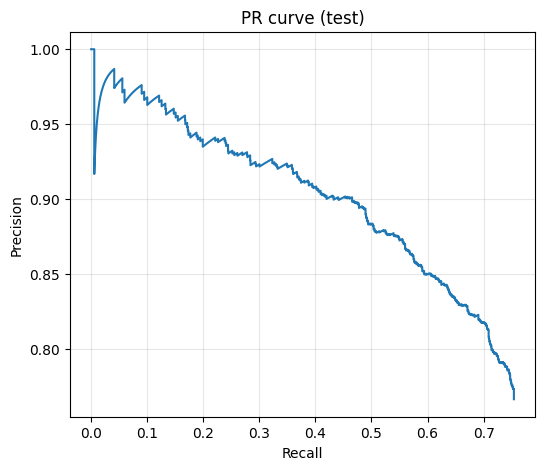

In [13]:
# Кривая precision-recall по test
plt.figure(figsize=(6, 5))
plt.plot(test_metrics['recall_curve'], test_metrics['precision_curve'])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR curve (test)')
plt.grid(alpha=0.3)
plt.show()

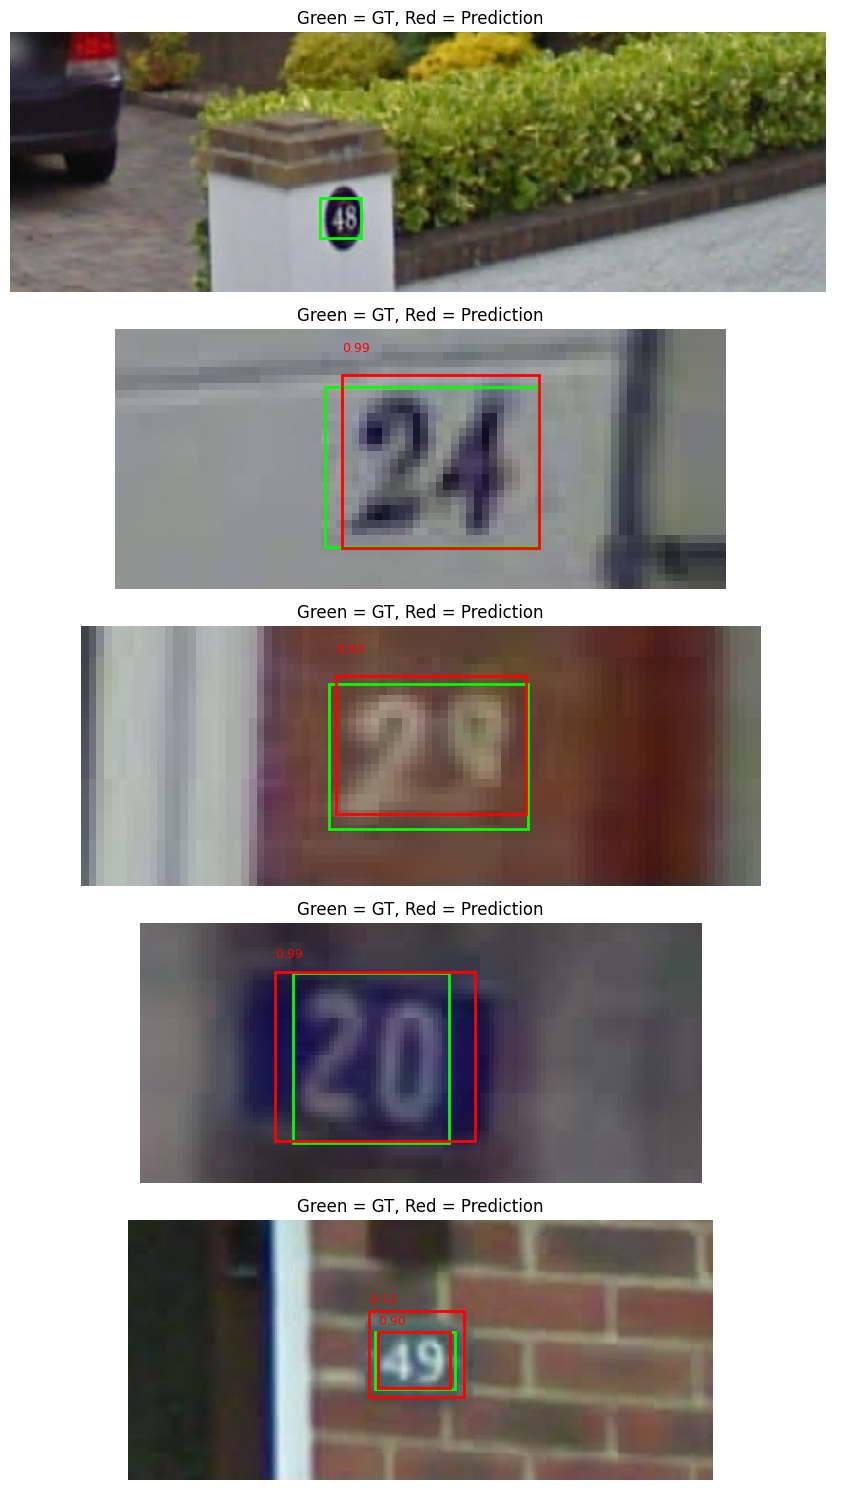

In [16]:
@torch.no_grad()
def visualize_test_predictions(model, dataset, device, n=6, score_threshold=0.5):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    plt.figure(figsize=(14, 3 * len(idxs)))
    for row_i, idx in enumerate(idxs, start=1):
        image, target = dataset[idx]
        out = model([image.to(device)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        plt.subplot(len(idxs), 1, row_i)
        plt.imshow(img_np)

        gt = target['boxes'][0].numpy()
        gx1, gy1, gx2, gy2 = gt
        plt.gca().add_patch(plt.Rectangle((gx1, gy1), gx2 - gx1, gy2 - gy1, fill=False, color='lime', linewidth=2))

        keep = out['scores'].cpu().numpy() >= score_threshold
        pboxes = out['boxes'].cpu().numpy()[keep]
        pscores = out['scores'].cpu().numpy()[keep]

        for b, s in zip(pboxes[:3], pscores[:3]):
            x1, y1, x2, y2 = b
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))
            plt.text(x1, max(0, y1 - 3), f'{s:.2f}', color='red', fontsize=9)

        plt.axis('off')
        plt.title('Green = GT, Red = Prediction')

    plt.tight_layout()
    plt.show()

vis_thr = TEST_SCORE_THRESHOLD if 'TEST_SCORE_THRESHOLD' in globals() else 0.5
visualize_test_predictions(model, test_ds, DEVICE, n=5, score_threshold=vis_thr)

## Детекция на собственных фото

Применим лучшую модель к своим фотографиям из папки `street-photos`. Отрисуем найденные bounding box'ы и уверенность модели.

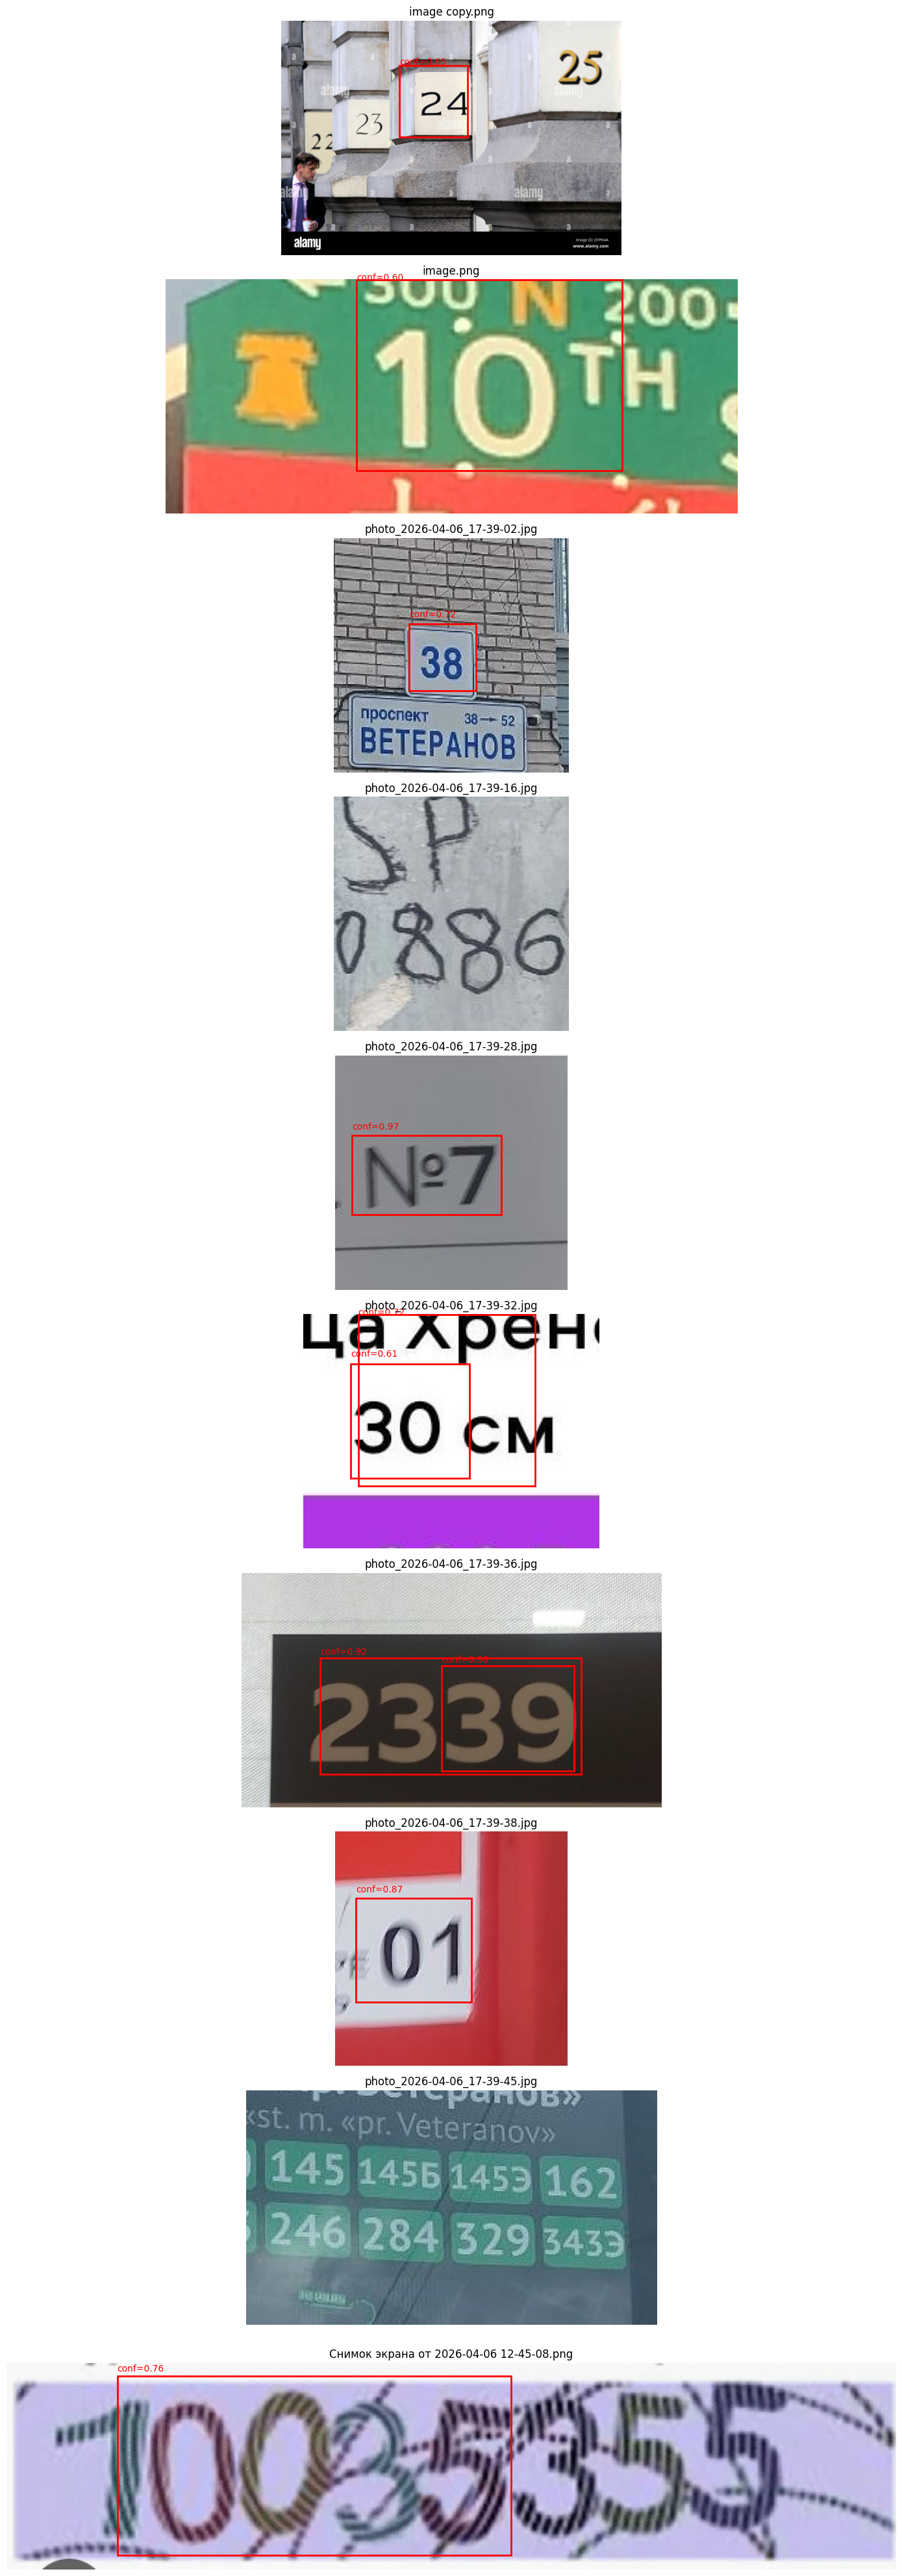

Итоги по фото:
- image copy.png: best_conf=0.65, bbox=[451, 172, 710, 445]
- image.png: best_conf=0.60, bbox=[130, 0, 310, 130]
- photo_2026-04-06_17-39-02.jpg: best_conf=0.72, bbox=[59, 67, 111, 120]
- photo_2026-04-06_17-39-16.jpg: детекций нет
- photo_2026-04-06_17-39-28.jpg: best_conf=0.97, bbox=[12, 63, 131, 125]
- photo_2026-04-06_17-39-32.jpg: best_conf=0.72, bbox=[36, 0, 157, 116]
- photo_2026-04-06_17-39-36.jpg: best_conf=0.92, bbox=[107, 115, 463, 274]
- photo_2026-04-06_17-39-38.jpg: best_conf=0.87, bbox=[15, 52, 107, 135]
- photo_2026-04-06_17-39-45.jpg: детекций нет
- Снимок экрана от 2026-04-06 12-45-08.png: best_conf=0.76, bbox=[102, 12, 467, 178]


In [18]:
@torch.no_grad()
def run_on_street_photos_detect_only(
    model,
    photo_dir: Path,
    device,
    score_threshold=0.5,
    max_detections_per_image=2,
    min_box_area=120
 ):
    model.eval()
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths = [p for p in sorted(photo_dir.glob('*')) if p.suffix.lower() in exts]

    if not paths:
        print('Добавь свои фото в папку:', photo_dir.resolve())
        return []

    results = []
    plt.figure(figsize=(14, 4 * len(paths)))
    for i, p in enumerate(paths, start=1):
        image = Image.open(p).convert('RGB')
        x = F.to_tensor(image)
        out = model([x.to(device)])[0]

        img_np = np.array(image)
        plt.subplot(len(paths), 1, i)
        plt.imshow(img_np)

        keep = out['scores'].cpu().numpy() >= score_threshold
        boxes = out['boxes'].cpu().numpy()[keep]
        scores = out['scores'].cpu().numpy()[keep]

        # Дополнительный фильтр мелких bbox + ограничение числа боксов
        filtered = []
        for b, s in zip(boxes, scores):
            x1, y1, x2, y2 = b
            area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
            if area >= min_box_area:
                filtered.append((b, s))

        filtered.sort(key=lambda t: float(t[1]), reverse=True)
        filtered = filtered[:max_detections_per_image]

        dets = []
        for b, s in filtered:
            x1, y1, x2, y2 = b
            x1i, y1i, x2i, y2i = int(x1), int(y1), int(x2), int(y2)
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2)
            )
            plt.text(x1, max(0, y1 - 5), f'conf={s:.2f}', color='red', fontsize=10)
            dets.append({'bbox': [x1i, y1i, x2i, y2i], 'conf': float(s)})

        results.append({'file': p.name, 'detections': dets})
        plt.title(p.name)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print('Итоги по фото:')
    for row in results:
        if not row['detections']:
            print(f"- {row['file']}: детекций нет")
        else:
            best = row['detections'][0]
            print(f"- {row['file']}: best_conf={best['conf']:.2f}, bbox={best['bbox']}")

    return results

street_detect_results = run_on_street_photos_detect_only(
    model,
    STREET_PHOTO_DIR,
    DEVICE,
    score_threshold=0.5,
    max_detections_per_image=2,
    min_box_area=120
)